In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

In [2]:
DATA_PROCESSED = Path('../data/processed')
deals = pd.read_parquet(DATA_PROCESSED / 'deals_clean.parquet')

In [3]:
print(deals.shape)
print(deals.dtypes)

(21593, 29)
Id                                     str
Deal Owner Name                        str
Closing Date                datetime64[us]
Quality                                str
Stage                                  str
Lost Reason                            str
Page                                   str
Campaign                               str
SLA                        timedelta64[us]
Content                                str
Term                                   str
Source                                 str
Payment Type                           str
Product                                str
Education Type                         str
Created Time                datetime64[us]
Course duration                    float64
Months of study                    float64
Initial Amount Paid                float64
Offer Total Amount                 float64
Contact Name                           str
City                                   str
Level of Deutsch                       str

# 05. Описательная статистика — Deals

**Цель:** получить общую картину распределения числовых и категориальных полей датасета Deals. Зафиксировать ключевые наблюдения для отчёта.

**Структура:**
1. Числовые поля — describe, мода, выбросы, визуализация распределений
2. Категориальные поля — частоты, доли, визуализация
3. Сводные выводы для отчёта

In [18]:
numeric_cols = ['Course duration', 'Months of study', 'Initial Amount Paid', 'Offer Total Amount']
deals[numeric_cols].describe().round(2)

,Course duration,Months of study,Initial Amount Paid,Offer Total Amount
count,3587.00,840.00,4165.00,4185.00
mean,10.20,5.44,950.09,7128.72
std,1.83,2.92,1422.15,4636.02
min,6.00,0.00,0.00,0.00
25%,11.00,3.00,300.00,3000.00
50%,11.00,5.00,1000.00,11000.00
75%,11.00,8.00,1000.00,11000.00
max,11.00,11.00,11500.00,11500.00


In [19]:
# Сводка только по Won Confirmed — для финансовой картины
won_stats = deals.loc[deals['is_won_confirmed'], numeric_cols].describe().round(2)
print(won_stats)

       Course duration  Months of study  Initial Amount Paid  \
count           839.00           839.00               839.00   
mean             10.18             5.45              1166.09   
std               1.85             2.92              1482.91   
min               6.00             1.00                 0.00   
25%              11.00             3.00               500.00   
50%              11.00             5.00              1000.00   
75%              11.00             8.00              1000.00   
max              11.00            11.00             11500.00   

       Offer Total Amount  
count              839.00  
mean              7536.71  
std               3751.37  
min                  0.00  
25%               4000.00  
50%              11000.00  
75%              11000.00  
max              11500.00  


In [5]:
print("Мода (самое частое значение):")
for col in numeric_cols:
    mode_val = deals[col].mode().iloc[0]  # mode() возвращает Series — берём первое
    count = (deals[col] == mode_val).sum()
    print(f"  {col}: {mode_val} (встречается {count} раз)")

Мода (самое частое значение):
  Course duration: 11.0 (встречается 3012 раз)
  Months of study: 6.0 (встречается 107 раз)
  Initial Amount Paid: 1000.0 (встречается 2623 раз)
  Offer Total Amount: 11000.0 (встречается 1860 раз)


## Основные выводы:
-- длительность курса - минимум 6 максимум 11 месяцев. То что 25, 50 и 75 персентиль показывает 11 - значит у 75% курс 11 месяцев, остальные 6 месяцев. 
-- количество месяцев обучения - также от 0 до 11. Мода  6 — то есть большинство студентов вне зависимости от курса сейчас на 6м месяце обучения
-- минимум платят 0 - но это аномалия, максимум 11500 за один раз. 
-- по предложению - клиенты платят от 0 до 11500, в среднем 7128, чаще всего 11000. 

## Анализ категориальных полей - качество, стадия, источник, продукт

## Stage

In [22]:
# Распределение по Stage (детально)
print("=== Stage (детально) ===")
stage_counts = deals['Stage'].value_counts(dropna=False)
stage_share = deals['Stage'].value_counts(normalize=True, dropna=False).round(3) * 100
stage_table = pd.DataFrame({'count': stage_counts, 'share_%': stage_share})
print(stage_table)

# Распределение по Stage_Group (агрегированно)
print("\n=== Stage_Group (по созданному флагу) ===")
sg_counts = deals['Stage_Group'].value_counts(dropna=False)
sg_share = deals['Stage_Group'].value_counts(normalize=True, dropna=False).round(3) * 100
sg_table = pd.DataFrame({'count': sg_counts, 'share_%': sg_share})
print(sg_table)

=== Stage (детально) ===
                           count  share_%
Stage                                    
Lost                       15743     72.9
Call Delayed                2248     10.4
Registered on Webinar       2072      9.6
Payment Done                 858      4.0
Waiting For Payment          325      1.5
Qualificated                 128      0.6
Registered on Offline Day    100      0.5
Need to Call - Sales          33      0.2
Need To Call                  31      0.1
Test Sent                     25      0.1
Need a consultation           23      0.1
New Lead                       6      0.0
Free Education                 1      0.0

=== Stage_Group (по созданному флагу) ===
             count  share_%
Stage_Group                
Lost         15743     72.9
In Progress   4991     23.1
Won            859      4.0


### Выводы по Stage и Stage_Group

**Воронка:**
- 73% сделок — Lost (15 743). Большой объём потерянных клиентов — основная зона для анализа.
- 23% — In Progress (4991). Лиды в разной степени готовности к покупке.
- 4% — Won (859). Конверсия по закрытым сделкам: **5.17%** (Won / (Won + Lost)).

**Структура In Progress по готовности:**
- "Тёплые" — Waiting For Payment (325), Test Sent (25) — близко к оплате
- "Средние" — Registered on Webinar (2072), Qualificated (128), Registered on Offline Day (100), Need a consultation (23) — вовлечены, но решение не принято
- "Холодные" — Call Delayed (2248), Need To Call (31+33), New Lead (6) — требуют активной работы менеджера

**Что бросается в глаза:**
- Call Delayed — самая массовая категория In Progress (2248, 45%). Возможны два прочтения: рабочая воронка с отложенным контактом или "кладбище" забытых лидов. Требует проверки на следующих шагах (через SLA, Lost Reason при переходе из Call Delayed).
- Free Education — 1 запись, edge case (вероятно сотрудник/партнёр).
- В Lost также есть дубликаты = 15 743 включает 1771 дубликат (10.7% Lost). После учёта дубликатов реальная конверсия должна быть выше.

## Quality

In [23]:
print("=== Quality (распределение) ===")
q_counts = deals['Quality'].value_counts(dropna=False)
q_share = deals['Quality'].value_counts(normalize=True, dropna=False).round(3) * 100
q_table = pd.DataFrame({'count': q_counts, 'share_%': q_share})
print(q_table)

=== Quality (распределение) ===
                   count  share_%
Quality                          
E - Non Qualified   7634     35.4
D - Non Target      6248     28.9
C - Low             3459     16.0
NaN                 2256     10.4
B - Medium          1564      7.2
A - High             432      2.0


### Выводы:

64% лидов (D + E) - нецелевые или неквалифицированные. Это значит что маркетинг привлекает много мусорных лидов либо -или  часть D/E лидов таки покупают и это не отражает картины?
Проверка — на этапе cross-tab Quality × Stage_Group.

## Source

In [24]:
print("=== Source (распределение) ===")
s_counts = deals['Source'].value_counts(dropna=False)
s_share = deals['Source'].value_counts(normalize=True, dropna=False).round(3) * 100
s_table = pd.DataFrame({'count': s_counts, 'share_%': s_share})
print(s_table)

=== Source (распределение) ===
                count  share_%
Source                        
Facebook Ads     4850     22.5
Google Ads       4226     19.6
Organic          2590     12.0
Tiktok Ads       2051      9.5
SMM              1730      8.0
Youtube Ads      1657      7.7
CRM              1656      7.7
Bloggers         1089      5.0
Telegram posts   1001      4.6
Webinar           379      1.8
Partnership       203      0.9
Test              159      0.7
Offline             2      0.0


### Выводы по Source

**Топ-3 канала по объёму лидов:**
- Facebook Ads — 4850 (22.5%)
- Google Ads — 4226 (19.6%)
- Organic — 2590 (12%) — бесплатный поток (SEO, прямые заходы)

Facebook + Google = 42% всех лидов. Высокая концентрация: просадка любого из них
сильно влияет на общий поток.

**Группировка каналов:**
- Paid (Facebook, Google, Tiktok, Youtube, Bloggers): ~64% лидов
- Organic/content (Organic, SMM, Telegram, Webinar): ~26%
- Partnership/internal (CRM, Partnership, Test, Offline): ~9%

## Product

In [25]:
print("=== Product (распределение) ===")
p_counts = deals['Product'].value_counts(dropna=False)
p_share = deals['Product'].value_counts(normalize=True, dropna=False).round(3) * 100
p_table = pd.DataFrame({'count': p_counts, 'share_%': p_share})
print(p_table)

=== Product (распределение) ===
                     count  share_%
Product                            
NaN                  18001     83.4
Digital Marketing     1990      9.2
UX/UI Design          1022      4.7
Web Developer          575      2.7
Find yourself in IT      4      0.0
Data Analytics           1      0.0


### Выводы
**Следствие для анализа:** все разрезы "по продуктам"
(CR, выручка, юнит-эка) считаются на подвыборке 17% сделок —
это надо учитывать в отчёте.

**Распределение по заполненным сделкам:**
- Digital Marketing — 1990 (55% от заполненных) — основной продукт
- UX/UI Design — 1022 (28%)
- Web Developer — 575 (16%)
- Find yourself in IT — 4, Data Analytics — 1 — edge cases,
  в продуктовом анализе не учитываются (нет статистики)

## Payment Type и Education Type

In [ ]:
print("=== Payment Type (после восстановления) ===")
pt_counts = deals['Payment Type'].value_counts(dropna=False)
pt_share = deals['Payment Type'].value_counts(normalize=True, dropna=False).round(3) * 100
pt_table = pd.DataFrame({'count': pt_counts, 'share_%': pt_share})
print(pt_table)

print("\n=== Payment Type среди Won Confirmed ===")
won_pt = deals.loc[deals['is_won_confirmed'], 'Payment Type'].value_counts(dropna=False)
won_pt_share = deals.loc[deals['is_won_confirmed'], 'Payment Type'].value_counts(normalize=True, dropna=False).round(3) * 100
won_pt_table = pd.DataFrame({'count': won_pt, 'share_%': won_pt_share})
print(won_pt_table)

print("\n=== Education Type ===")
et_counts = deals['Education Type'].value_counts(dropna=False)
et_share = deals['Education Type'].value_counts(normalize=True, dropna=False).round(3) * 100
et_table = pd.DataFrame({'count': et_counts, 'share_%': et_share})
print(et_table)

print("\n=== Education Type среди Won Confirmed ===")
won_et = deals.loc[deals['is_won_confirmed'], 'Education Type'].value_counts(dropna=False)
won_et_share = deals.loc[deals['is_won_confirmed'], 'Education Type'].value_counts(normalize=True, dropna=False).round(3) * 100
won_et_table = pd.DataFrame({'count': won_et, 'share_%': won_et_share})
print(won_et_table)

=== Payment Type (после восстановления) ===
                    count  share_%
Payment Type                      
NaN                 20619     95.5
Recurring Payments    812      3.8
One Payment           157      0.7
Reservation             5      0.0

=== Payment Type среди Won Confirmed ===
                    count  share_%
Payment Type                      
Recurring Payments    711     84.7
One Payment           126     15.0
Reservation             1      0.1
NaN                     1      0.1

=== Education Type ===
                count  share_%
Education Type                
NaN             18294     84.7
Morning          2895     13.4
Evening           404      1.9

=== Education Type среди Won Confirmed ===
                count  share_%
Education Type                
Morning           662     78.9
Evening           170     20.3
NaN                 7      0.8


### Выводы по Payment Type и Education Type

Оба поля заполняются на поздних стадиях воронки — поэтому общий разрез
показывает ~95% NaN. Финансовый смысл имеют только в выборке Won Confirmed.

#### Payment Type среди Won

- **Recurring Payments — 711 (84.7%)** — подавляющее большинство платит помесячно
- One Payment — 126 (15%) — единоразовая оплата (полная или частичная)
- Reservation — 1, NaN — 1 — edge cases

**Бизнес-следствие:** школа работает в модели "подписки на образование" —
~85% выручки распределено во времени на 6-11 месяцев, не получено разово
в момент сделки. Для оценки фактических поступлений в кассу
нужно учитывать Months of study, не только факт Payment Done.

#### Education Type среди Won

- **Morning — 662 (78.9%)** — почти 4 из 5 студентов учатся утром
- Evening — 170 (20.3%)

Сильный перекос в Morning. Вероятное объяснение для Германии: значительная
часть аудитории — люди в процессе переквалификации, использующие Gutschein
от Arbeitsamt, который подразумевает full-time дневное обучение.
Evening — небольшой сегмент работающих учеников.

**Гипотеза для дальнейшей проверки:** различия в воронке Morning vs Evening
(CR, время до оплаты, LTV) могут стать основой для A/B-теста или
тактического вывода (например, наращивать ли Evening сегмент).

## Lost Reason

In [30]:
print("=== Lost Reason (все сделки) ===")
lr_counts = deals['Lost Reason'].value_counts(dropna=False)
lr_share = deals['Lost Reason'].value_counts(normalize=True, dropna=False).round(3) * 100
lr_table = pd.DataFrame({'count': lr_counts, 'share_%': lr_share})
print(lr_table)

print("\n=== Lost Reason только у Stage = Lost ===")
lost_only = deals[deals['Stage'] == 'Lost']
lr_lost = lost_only['Lost Reason'].value_counts(dropna=False)
lr_lost_share = lost_only['Lost Reason'].value_counts(normalize=True, dropna=False).round(3) * 100
lr_lost_table = pd.DataFrame({'count': lr_lost, 'share_%': lr_lost_share})
print(lr_lost_table)

print("\n=== Lost Reason при Stage != Lost (history leak / Next stream) ===")
not_lost = deals[(deals['Stage'] != 'Lost') & deals['Lost Reason'].notna()]
lr_other = not_lost['Lost Reason'].value_counts()
print(lr_other)

=== Lost Reason (все сделки) ===
                                         count  share_%
Lost Reason                                            
NaN                                       5469     25.3
Doesn't Answer                            4135     19.1
Changed Decision                          2146      9.9
Duplicate                                 1771      8.2
Non target                                1761      8.2
Stopped Answering                         1588      7.4
Invalid number                            1481      6.9
needs time to think                        655      3.0
Expensive                                  626      2.9
Conditions are not suitable                531      2.5
Next stream                                288      1.3
Inadequate                                 176      0.8
Gutstein refusal                           172      0.8
Considering a different direction in IT    148      0.7
Not for myself                             145      0.7
Does not speak 

### Выводы по Lost Reason

22 категориизаполнены у 99.7% Lost-сделок

#### Природа потерь (структура Lost)

**Контактные потери (~52%):**
- Doesn't Answer — 25.9%
- Stopped Answering — 9.9%
- Invalid number — 9.3%
- Didn't leave an application — 0.8%

Половина Lost — это лиды, до которых менеджер не дозвонился или
которые перестали отвечать. Не "не купили", а "не было разговора".

**Не подходят как клиенты (~22%):**
- Duplicate — 11.1% (дубли)
- Non target — 11%
- Прочие (Inadequate, Does not speak English, Not for myself,
  Computer skills, Considering other direction) — ~5%

Структурно нецелевые / технические отвалы.

**Возражения по продукту/цене (~10%):**
- Changed Decision — 13.5% (обтекаемое "передумал")
- Expensive — 3.9%
- Conditions are not suitable — 3.3%
- Gutstein refusal — 1%
- The contract did not fit — 0.1%

Реальные продуктовые возражения. Из них только ~3.9% — про цену.

**Раздумье / отложенные (~5%):**
- needs time to think — 3.8%
- Next stream — 0.8%
- Thought for free — 0.7%

**К конкурентам:** Went to Rivals — 0.3%

#### Ключевые наблюдения

1. **Реальные продуктовые возражения — только ~10% Lost** (~2300 сделок).
   Остальные 90% — это потери на стадии контакта или нецелевые лиды.
   Большая часть "конверсионной проблемы" школы не в продукте,
   а в качестве лидогенерации и работе менеджеров на дозвоне.

2. **Doesn't Answer (25.9%) — самая большая зона потерь.**
   Требует углублённого анализа: связь с Quality, SLA, Source.

3. **Цена — слабое возражение** (3.9% Lost). Это даёт понять,
   что снижение цены вряд ли решит главную проблему воронки.

4. **Gutstein refusal — 1%.** Подтверждает: Gutschein — часть бизнес-модели.
   Школа в основном работает с теми, кто получает субсидию;
   без неё конверсия резко падает.

5. **Duplicate — 11.1% Lost (1746 сделок).** Подтверждает дубликаты
   в лидах. При расчёте реальной конверсии — учесть в знаменателе.

#### Lost Reason при Stage ≠ Lost (428 случаев)

- Next stream (157) — легитимное использование: лид перенесён
  на следующий поток, не отвалился.
- Остальные ~270 — history leak: менеджер сменил стадию,
  но Lost Reason не очистил. Технический мусор, на анализ не влияет
  (фильтруется через Stage == 'Lost').

## SLA 

In [13]:
deals['SLA_hours'] = deals['SLA'].dt.total_seconds() / 3600
print(deals['SLA_hours'].describe().round(2))

count    15533.00
mean        32.17
std        204.79
min          0.00
25%          1.22
50%          5.53
75%         15.64
max       7474.57
Name: SLA_hours, dtype: float64


## Графики

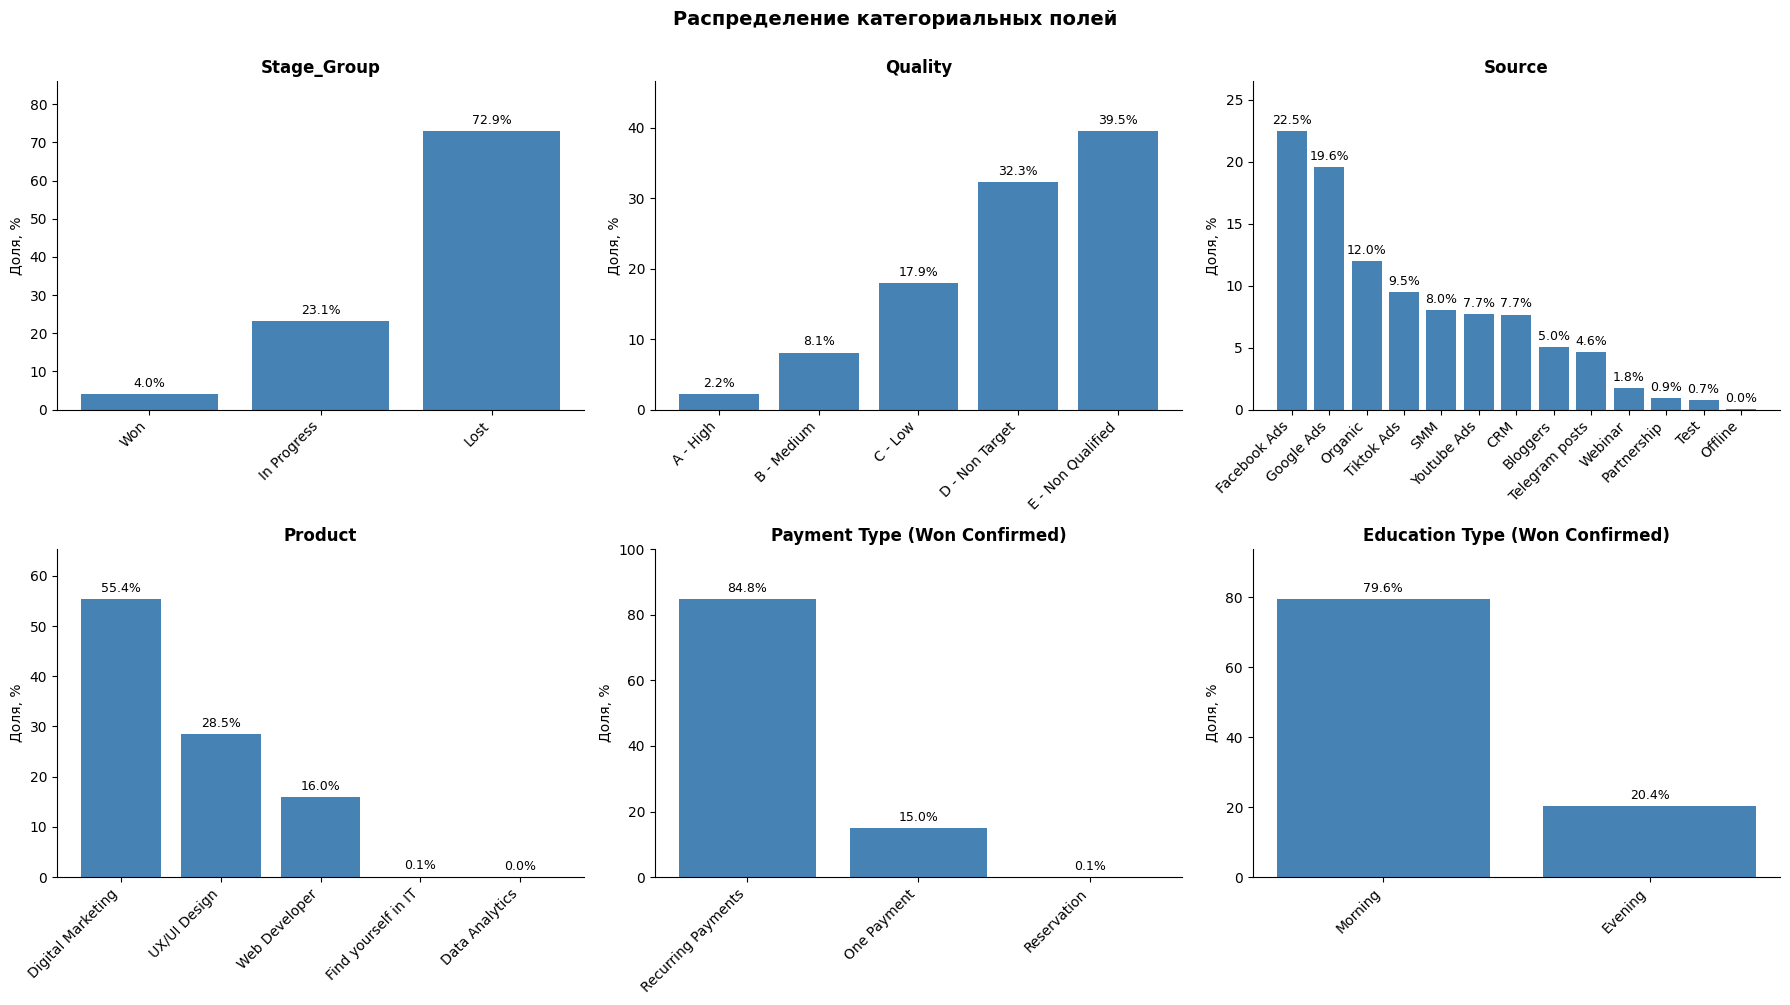

In [32]:
# Конфиг: поле, использовать только Won, кастомный порядок (если нужен)
configs = [
    ('Stage_Group',    False, ['Won', 'In Progress', 'Lost']),
    ('Quality',        False, ['A - High', 'B - Medium', 'C - Low',
                               'D - Non Target', 'E - Non Qualified']),
    ('Source',         False, None),                    # по убыванию
    ('Product',        False, None),                    # по убыванию, без NaN
    ('Payment Type',   True,  None),                    # только Won
    ('Education Type', True,  ['Morning', 'Evening']),  # только Won
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, won_only, order) in zip(axes, configs):
    data = deals[deals['is_won_confirmed']] if won_only else deals
    
    # Доли в %, без NaN
    counts = data[col].value_counts(dropna=True, normalize=True) * 100
    
    if order:
        counts = counts.reindex(order).dropna()
    else:
        counts = counts.sort_values(ascending=False)
    
    bars = ax.bar(range(len(counts)), counts.values, color='steelblue')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha='right')
    
    title_suffix = ' (Won Confirmed)' if won_only else ''
    ax.set_title(f'{col}{title_suffix}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Доля, %')
    
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.set_ylim(0, counts.max() * 1.18)  # запас сверху для подписей
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Распределение категориальных полей', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Lost Reason 

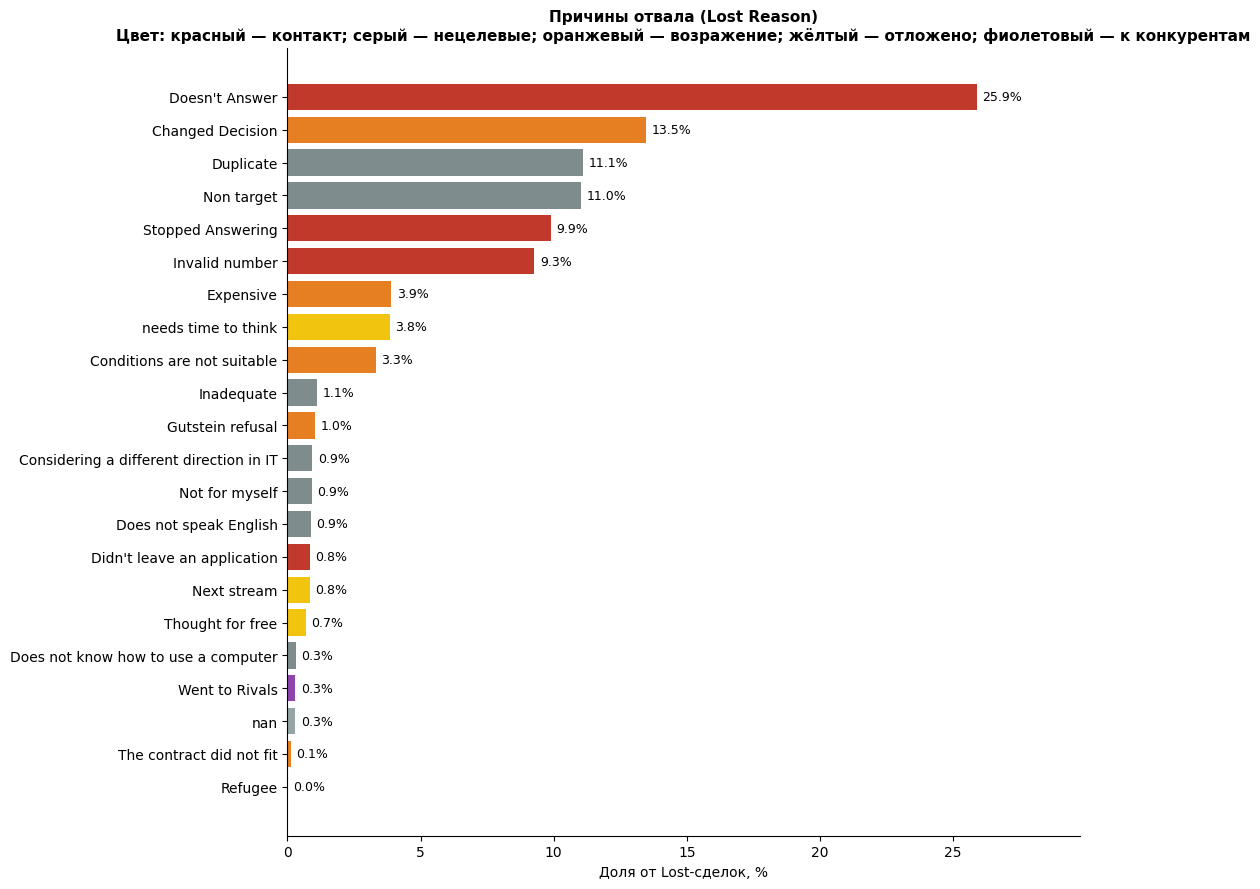

In [33]:
# Только реально потерянные сделки
lost = deals[deals['Stage'] == 'Lost']
lr_share = lost['Lost Reason'].value_counts(normalize=True, dropna=False) * 100
lr_share = lr_share.sort_values(ascending=True)  # для горизонтального бара — снизу вверх

# Группировка по природе отвала — цветовая кодировка
contact_loss = {'Doesn\'t Answer', 'Stopped Answering', 'Invalid number',
                "Didn't leave an application"}
not_client = {'Duplicate', 'Non target', 'Inadequate', 'Does not speak English',
              'Not for myself', 'Considering a different direction in IT',
              'Does not know how to use a computer', 'Refugee'}
product_objection = {'Changed Decision', 'Expensive', 'Conditions are not suitable',
                     'Gutstein refusal', 'The contract did not fit'}
postponed = {'needs time to think', 'Next stream', 'Thought for free'}
rivals = {'Went to Rivals'}

def get_color(reason):
    if reason in contact_loss:       return '#c0392b'  # красный — контакт не получился
    if reason in not_client:         return '#7f8c8d'  # серый — не наши
    if reason in product_objection:  return '#e67e22'  # оранжевый — возражение
    if reason in postponed:          return '#f1c40f'  # жёлтый — отложено
    if reason in rivals:             return '#8e44ad'  # фиолетовый — к конкурентам
    return '#95a5a6'

colors = [get_color(r) for r in lr_share.index]

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(range(len(lr_share)), lr_share.values, color=colors)
ax.set_yticks(range(len(lr_share)))
ax.set_yticklabels(lr_share.index)
ax.set_xlabel('Доля от Lost-сделок, %')
ax.set_title('Причины отвала (Lost Reason)\n'
             'Цвет: красный — контакт; серый — нецелевые; '
             'оранжевый — возражение; жёлтый — отложено; фиолетовый — к конкурентам',
             fontsize=11, fontweight='bold')

ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_xlim(0, lr_share.max() * 1.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

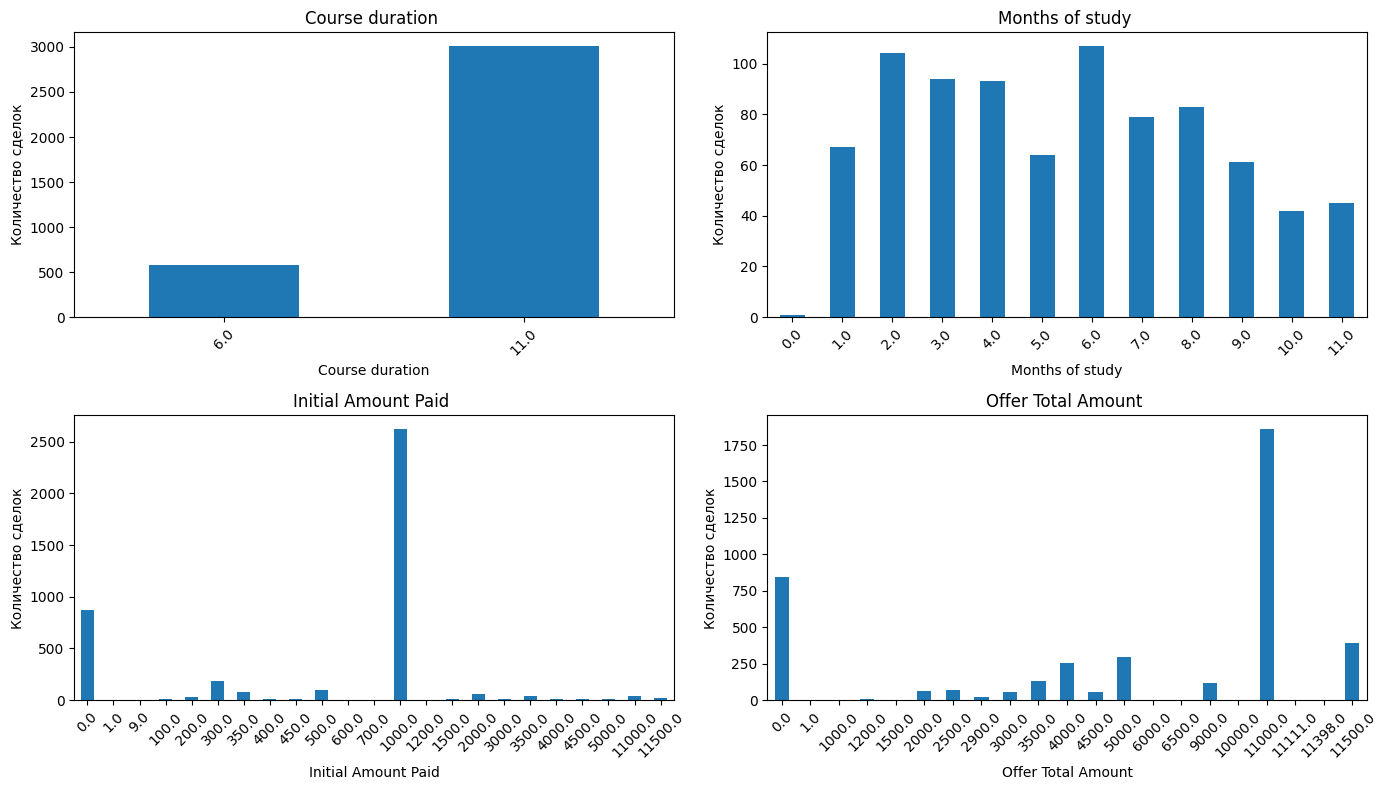

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    top_values = deals[col].value_counts().sort_index()
    top_values.plot(kind='bar', ax=ax)
    ax.set_title(f'{col} ')
    ax.set_xlabel(col)
    ax.set_ylabel('Количество сделок')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Выводы из данных 

- **Course duration**: мы видим по графикам, что есть курсы 6 и 11 месяцев. Наиболее часто люди покупают курс на 11 месяцев. 

- **Months of study**: это те люди которые активно на данный момент учатся, то есть показывает распределение сколько сейчас учеников на каждом месяце обучения. Снижение количества учеников на 9-11 месяцах обучения может объясняться двумя версиями: либо отсевом, либо тем, что объём продаж был ниже год назад относительно текущего момента. Проверим потом при сопоставлении  с тенденцией создания сделок по месяцам. Но в целом из этого графика можно сказать что каждый месяц в школе занимаются в среднем больше 60 учеников.

- **Initial Amount Paid**: это то, сколько клиентов заплатили первым платежом - может быть вся сумма, может быть часть. Видим, что в основном люди платят 1000 евро первым платежом. Следущая по частоте оплат - 300 евро. МНого 0, но как это интерпретировать - то ли пробный курс - то ли на стадии подписания договора, но оплата еще в любом случает не дошла. 


- **Offer Total Amount**: полная стоимость обучения по договору - сколько клиент заплатит когда доучится. Самое частое значение 11000 евро, максимум 11500, минимум 0 - вероятно это пробное обучение, либо артефакты. 

- **SLA**: - время ответа продажника. время с того момента как лид отправил заявку и менеджер связался. В среднем 32 часа (что-то много - полтора суток), максимум 7474 сама - 311 суток - похоже на выброс или аномалию. Минимум 0 часов - то есть почти мгновенно. 


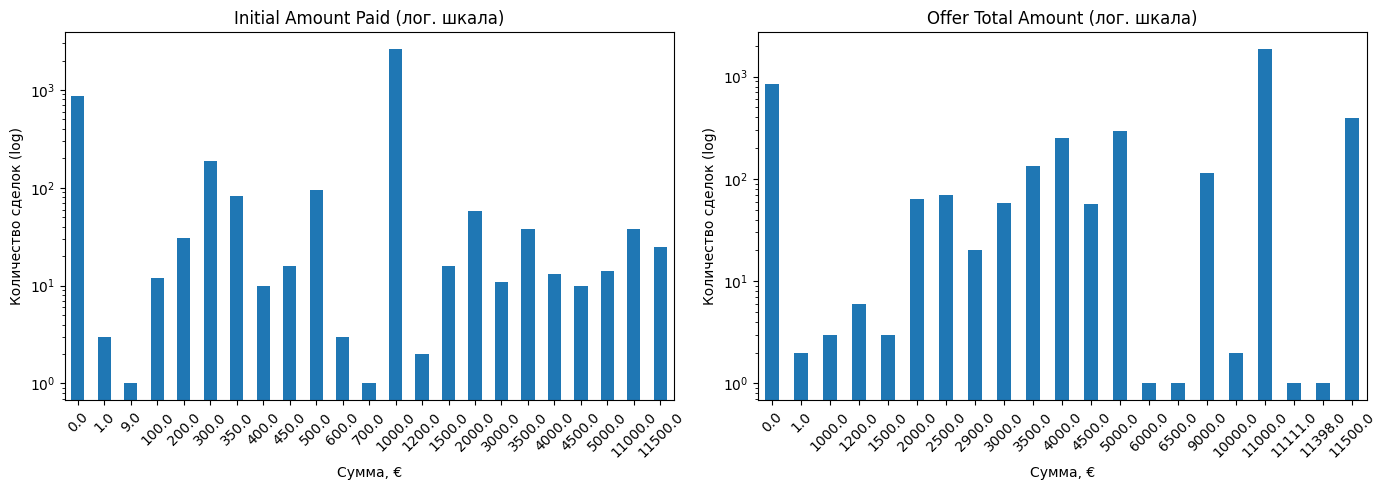

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Initial Amount Paid с log scale
top_initial = deals['Initial Amount Paid'].value_counts().sort_index()
top_initial.plot(kind='bar', ax=axes[0])
axes[0].set_title('Initial Amount Paid (лог. шкала)')
axes[0].set_yscale('log')  # ВОТ ЭТО — лог-шкала
axes[0].set_xlabel('Сумма, €')
axes[0].set_ylabel('Количество сделок (log)')
axes[0].tick_params(axis='x', rotation=45)

# Offer Total Amount с log scale
top_offer = deals['Offer Total Amount'].value_counts().sort_index()
top_offer.plot(kind='bar', ax=axes[1])
axes[1].set_title('Offer Total Amount (лог. шкала)')
axes[1].set_yscale('log')
axes[1].set_xlabel('Сумма, €')
axes[1].set_ylabel('Количество сделок (log)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [16]:
deals[deals['Course duration'].notna()].groupby('Product')['Course duration'].agg(['mean', 'median', 'count'])

,mean,median,count
Product,,,
Digital Marketing,11.0,11.0,1990
UX/UI Design,11.0,11.0,1022
Web Developer,6.0,6.0,575
